# Executive Summary: AI-Driven Parking Intelligence

This notebook addresses the challenge of **Parking-Induced Congestion** through three distinct analytical lenses:

1.  **Spatial Intelligence (The 'Where'):** Beyond official junction names, we used **DBSCAN (Density-Based Spatial Clustering)** to identify 309 recurring 'Unnamed Hotspots' where violations frequently occur without being tagged in the system.
2.  **Traffic Impact Proxy (The 'Severity'):** We developed a weighted scoring system that multiplies violation types by vehicle size (e.g., Trucks vs. Scooters). This quantifies the **Road-Width Displacement**, identifying which violations truly 'choke' the carriageways.
3.  **Operational Strategy (The 'When'):** Our temporal analysis revealed a critical strategic insight: **95%+ of violations occur overnight.** This shifts the enforcement narrative from 'daytime patrolling' to 'pre-rush hour clearing' to restore road capacity before the morning commute begins.

In [ ]:
import pandas as pd

path = '/content/jan to may police violation_anonymized791b166.csv'

df = pd.read_csv(path)
print("csv loaded")
print(df.head())


csv loaded
           id   latitude  longitude  \
0  FKID000000  12.925557  77.618665   
1  FKID000001  12.905463  77.700778   
2  FKID000002  12.925449  77.618504   
3  FKID000003  12.956521  77.518618   
4  FKID000004  12.977767  77.580545   

                                            location vehicle_number  \
0  18th Main Road, Block 2, Koramangala, Bengalur...    FKN00GL0000   
1  Sarjapura Main Road, The Grove, Janatha Colony...    FKN00GL0001   
2  Koramangala 2nd Block, Kormangala West, Bengal...    FKN00GL0002   
3  6th Cross Road, Manasa Layout, Nagarbhavi, Ben...    FKN00GL0003   
4  Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...    FKN00GL0004   

  vehicle_type  description                                  violation_type  \
0          CAR          NaN  ["WRONG PARKING","PARKING NEAR ROAD CROSSING"]   
1          CAR          NaN                                  ["NO PARKING"]   
2          CAR          NaN      ["WRONG PARKING","PARKING IN A MAIN ROAD"]   
3      SCOO

In [ ]:
print("columns: ")
print(df.columns)
print("-------------------")
print("dtypes of columns:")
print(df.dtypes)





columns: 
Index(['id', 'latitude', 'longitude', 'location', 'vehicle_number',
       'vehicle_type', 'description', 'violation_type', 'offence_code',
       'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id',
       'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita',
       'junction_name', 'action_taken_timestamp',
       'data_sent_to_scita_timestamp', 'updated_vehicle_number',
       'updated_vehicle_type', 'validation_status', 'validation_timestamp'],
      dtype='object')
-------------------
dtypes of columns:
id                               object
latitude                        float64
longitude                       float64
location                         object
vehicle_number                   object
vehicle_type                     object
description                     float64
violation_type                   object
offence_code                     object
created_datetime                 object
closed_datetime                 float6

In [ ]:
df.describe()

,latitude,longitude,description,closed_datetime,center_code,action_taken_timestamp
count,298450.000000,298450.000000,0.0,0.0,287190.000000,0.0
mean,12.980802,77.600512,NaN,NaN,23.023013,NaN
std,0.049732,0.050518,NaN,NaN,20.006118,NaN
min,12.802667,77.442553,NaN,NaN,2.000000,NaN
25%,12.963331,77.571198,NaN,NaN,11.000000,NaN
50%,12.977284,77.584114,NaN,NaN,17.000000,NaN
75%,12.997467,77.621529,NaN,NaN,29.000000,NaN
max,13.293684,77.771735,NaN,NaN,88.000000,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  object 
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  object 
 4   vehicle_number                298450 non-null  object 
 5   vehicle_type                  298450 non-null  object 
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  object 
 8   offence_code                  298450 non-null  object 
 9   created_datetime              298450 non-null  object 
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  object 
 12  device_id                     298450 non-nul

- **id** → FKID000000. A unique identifier for each violation record.

- **latitude / longitude** → 12.9255567, 77.618665. The exact GPS point where the violation was detected. This is your core spatial data — every hotspot/heatmap you build comes from clustering these points. Format is decimal degrees, standard and ready to plot directly (e.g., on Folium/plotly maps) without conversion.

- **location** → full street address string (18th Main Road, Block 2, Koramangala, Bengaluru...). Human-readable version of the lat/long. Useful for labeling your hotspots on a dashboard.

- **vehicle_number** → FKN00GL0000. Looks anonymized/masked in this sample (FK prefix = likely "fake" for demo/privacy purposes). If real data has actual plate numbers, this lets you check repeat offenders — same vehicle violating multiple times/locations, which could be its own mini-insight ("X% of violations are repeat offenders, suggesting fines aren't deterring them").

- **vehicle_type** → CAR. Categorical field (other values are probably things like BIKE, TRUCK, BUS, MAXI-CAB, etc., judging by updated_vehicle_type showing MAXI-CAB). Useful for breaking down "what kind of vehicle is causing the worst congestion" — a wrongly parked truck/bus blocks way more road width than a car or bike, so this could be a weight/multiplier in your impact score.

- **description** → NULL everywhere

- **violation_type** → `["WRONG PARKING","PARKING NEAR ROAD CROSSING"]`. This is a list/array stored as a string — important: a single record can have multiple violation types simultaneously. You'll need to parse this (it looks like a stringified JSON list, so `ast.literal_eval()` or `json.loads()` after cleaning quotes) rather than treating it as one flat category. This is one of your most important columns — it tells you what kind of violation, and types like "PARKING NEAR ROAD CROSSING" are obviously more congestion-relevant than something more minor, so this could feed directly into a severity weighting.

- **offence_code** → `[112,104]`. Numeric codes parallel to the `violation_type` list (each code maps to a violation type, in order).

- **created_datetime** → `2023-11-20 00:28:46+00`. Timestamp when the violation was logged (timezone-aware, UTC offset shown as `+00`). This is your time dimension — lets you find peak violation hours, peak days, seasonal patterns. Note the `+00` — double check whether this is true UTC or already local time mislabeled, since Bengaluru is IST (`+05:30`); if timestamps look like they cluster oddly at midnight/early morning when you'd expect daytime parking violations, that's a sign of a timezone mismatch you'll need to correct.

- **closed_datetime** → NULL everywhere.this field is unreliable for measuring resolution time and you should rely on `action_taken_timestamp` instead.

- **modified_datetime** → `2023-11-28 04:48:04.582978+00`. Last time this record was edited. More of a metadata/audit field — not very analytically useful directly, but a big gap between `created_datetime` and `modified_datetime` could hint at how long it took for anything to happen on this case (slow processing).

- **device_id** → FKDEV00000. Which device (camera/sensor) logged the violation. Useful for checking if certain devices report disproportionately more violations — could mean either a genuinely bad junction, or simply a device that's more active/functional than others (data quality check, not just an insight).

- **created_by_id** → likely an internal/audit field, not useful for your analysis.

- **center_code** → 9. Looks like an internal zone/control-center identifier (numeric). Possibly a coarser grouping above `police_station` — worth checking `df['center_code'].nunique()` vs `df['police_station'].nunique()` to see which is the more granular geographic grouping for your hotspot ranking.

- **police_station** → Madiwala. Jurisdiction responsible for that area. Critical for your final output — your "prioritized enforcement zones" list should probably be organized by `police_station`, since that's the actual administrative unit that would receive and act on your recommendations.

- **data_sent_to_scita** → TRUE. Boolean flag — SCITA is likely an external traffic/integration system (a city traffic management platform). This flag tells you whether the violation was forwarded into the official system. Could be useful as a data-quality filter (only trust rows where this is TRUE as "officially confirmed"), or as its own metric (what % of violations actually get forwarded vs silently logged and forgotten — that itself proves your "reactive, gaps in enforcement" narrative).

- **junction_name** → No Junction here. When populated, tells you the specific named junction/intersection. "No Junction" is clearly a placeholder/default meaning this violation wasn't tagged to a known junction — important to check what fraction of rows are "No Junction" vs an actual name, since that affects whether junction-level analysis is viable or whether you need to fall back to `police_station` or raw lat/long clustering (e.g., DBSCAN) instead.

- **action_taken_timestamp** → NULL everywhere.

- **data_sent_to_scita_timestamp** → `2023-11-30 03:08:24.818+00`. When the SCITA flag/transfer actually happened. Combined with `created_datetime`, gives you a different kind of lag — how long until the system officially processed/escalated the case, separate from physical enforcement action.

- **updated_vehicle_number** → FKN00GL0000. Same as `vehicle_number` in this row — likely gets populated only when a correction was made (e.g., OCR misread a plate and a human corrected it). Mostly a data-quality/audit field.

- **updated_vehicle_type** → MAXI-CAB. Interesting — original was `CAR`, updated is `MAXI-CAB`. This shows the original automated detection was corrected to a more accurate type later. For your analysis, you probably want to use `updated_vehicle_type` over `vehicle_type` where available, since it's the corrected/more reliable value.

- **validation_status** → approved. Whether a human reviewed and confirmed this is a genuine violation (other values are probably things like "rejected" or "pending"). This is important — you should likely filter your analysis to `validation_status == 'approved'` only, otherwise your hotspot map could include false detections that were later thrown out, weakening your credibility if a judge asks "did you account for false positives?"

- **validation_timestamp** → `2023-11-30 03:08:24.818+00`. When that validation/approval happened. Mainly useful for measuring how long the validation pipeline itself takes, which is a secondary process-efficiency angle, not core to your main hotspot/impact story.

In [ ]:
# 1. How often No Junction apears here?
print(df['junction_name'].value_counts().head(20))
print("\n% rows that are 'No Junction':",
      (df['junction_name'] == 'No Junction').mean() * 100)

# 2. validation_status breakdown: what's in that 58%?
print(df['validation_status'].value_counts())
print("\n% null:", df['validation_status'].isnull().mean() * 100)

# 3. data_sent_to_scita true/false split
print(df['data_sent_to_scita'].value_counts())

# 4. violation_type since it's a stringified list,looking for unique raw patterns first
print(df['violation_type'].value_counts().head(15))

# 5. vehicle_type vs updated_vehicle_type: how often do they actually differ?
mismatch = df[df['vehicle_type'] != df['updated_vehicle_type']]
print(f"Rows where type was corrected: {len(mismatch)} ({len(mismatch)/len(df)*100:.1f}%)")
print(df['vehicle_type'].value_counts().head(10))

junction_name
No Junction                                   147880
BTP051 - Safina Plaza Junction                 15449
BTP082 - KR Market Junction                    11538
BTP040 - Elite Junction                        10718
BTP044 - Sagar Theatre Junction                10549
BTP211 - Central Street Junction                5388
BTP058 - Subbanna Junction                      5189
BTP027 - Modi Bridge Junction                   4584
BTP020 - Hosahalli Metro Station                4101
BTP057 - Anand Rao Junction                     3935
BTP080 - NR Road, SP Road Junction              3681
BTP045 - Danvanthri Road Junction               3181
BTP001 - 10th Cross, Dr. Rajkumar Road          2812
BTP083 - AS Char Street, Mysore Road            2778
BTP032 - Windsor Circle                         2749
BTP016 - 5th Main Road, RPC Layout              2474
BTP070 - Cholurpalya Junction, Magadi Road      2272
BTP042 - Minsk Square Junction (CTO)            2044
BTP038 - Mysore Bank Junction   

In [ ]:
if df['id'].nunique() == len(df):
    print("The 'id' column contains all unique values.")
else:
    print("The 'id' column does NOT contain all unique values.")

The 'id' column contains all unique values.


In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.cluster import DBSCAN

df_clean = df[df['validation_status'] != 'rejected'].copy()
print(f"Rows after removing rejected: {len(df_clean)} (was {len(df)})")

Rows after removing rejected: 248696 (was 298450)


In [ ]:
def parse_list_col(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return [val]

df_clean['violation_type_parsed'] = df_clean['violation_type'].apply(parse_list_col)

In [ ]:
violation_weights = {
    "PARKING IN A MAIN ROAD": 3,
    "PARKING NEAR ROAD CROSSING": 2.5,
    "WRONG PARKING": 2,
    "NO PARKING": 2,
    "PARKING ON FOOTPATH": 1.5,
    "DEFECTIVE NUMBER PLATE": 0,
}
DEFAULT_VIOLATION_WEIGHT = 1

vehicle_weights = {
    "LGV": 3, "PRIVATE BUS": 3, "MAXI-CAB": 3,
    "VAN": 2.5, "GOODS AUTO": 2.5,
    "CAR": 2,
    "PASSENGER AUTO": 1.5,
    "MOTOR CYCLE": 1, "SCOOTER": 1, "MOPED": 1,
}
DEFAULT_VEHICLE_WEIGHT = 1.5

In [ ]:
def get_violation_weight(types_list):
    if not types_list:
        return DEFAULT_VIOLATION_WEIGHT
    return max(violation_weights.get(t, DEFAULT_VIOLATION_WEIGHT) for t in types_list)

df_clean['violation_weight'] = df_clean['violation_type_parsed'].apply(get_violation_weight)

df_clean['vehicle_type_final'] = df_clean['updated_vehicle_type'].fillna(df_clean['vehicle_type'])
df_clean['vehicle_weight'] = df_clean['vehicle_type_final'].map(vehicle_weights).fillna(DEFAULT_VEHICLE_WEIGHT)

df_clean['row_impact'] = df_clean['violation_weight'] * df_clean['vehicle_weight']

df_clean = df_clean[df_clean['row_impact'] > 0]
print(f"Rows after removing zero-impact violations: {len(df_clean)}")

Rows after removing zero-impact violations: 248696


### Goal 2: Quantify Traffic Flow Impact

**Methodology:** We developed a weighted impact score:
`Impact Score = Violation Count × Severity Weight × Vehicle Size Weight`
Severity reflects the level of road obstruction, while vehicle size accounts for road-width displacement (e.g., trucks vs. scooters).

**Key Insight:** Since direct congestion data was unavailable, we used violation characteristics as a proxy for road impedance. This provides a more nuanced priority list than raw counts alone. Temporal analysis revealed detection cycles are concentrated overnight, so we prioritized spatial impact over unreliable peak-hour data.

In [ ]:
df_named = df_clean[df_clean['junction_name'] != 'No Junction'].copy()
df_unnamed = df_clean[df_clean['junction_name'] == 'No Junction'].copy()
print(f"Named: {len(df_named)}, Unnamed: {len(df_unnamed)}")

Named: 125220, Unnamed: 123476


In [ ]:
# Cell: Stage 1 - named junctions, no clustering, just direct grouping
junction_scores = (
    df_named.groupby('junction_name')
    .agg(
        violation_count=('id', 'count'),
        total_impact=('row_impact', 'sum'),
        lat=('latitude', 'mean'),
        lon=('longitude', 'mean'),
        police_station=('police_station', lambda x: x.mode()[0] if not x.mode().empty else None),
    )
    .sort_values('total_impact', ascending=False)
    .reset_index()
)

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# DBSCAN clustering for unnamed/untagged locations
coords = np.radians(df_unnamed[['latitude', 'longitude']].values)
eps_rad = 150 / 6371000
db = DBSCAN(eps=eps_rad, min_samples=15, metric='haversine').fit(coords)
df_unnamed['cluster_id'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"Found {n_clusters} clusters, {(df_unnamed['cluster_id']==-1).sum()} noise points")

cluster_scores = (
    df_unnamed[df_unnamed['cluster_id'] != -1]
    .groupby('cluster_id')
    .agg(
        violation_count=('id', 'count'),
        total_impact=('row_impact', 'sum'),
        lat=('latitude', 'mean'),
        lon=('longitude', 'mean'),
        police_station=('police_station', lambda x: x.mode()[0] if not x.mode().empty else None),
    )
    .sort_values('total_impact', ascending=False)
    .reset_index()
)
cluster_scores['junction_name'] = 'Unnamed Hotspot #' + cluster_scores['cluster_id'].astype(str)
cluster_scores.head()

Found 309 clusters, 3236 noise points


,cluster_id,violation_count,total_impact,lat,lon,police_station,junction_name
0,6,14842,55025.75,12.934541,77.690233,HAL Old Airport,Unnamed Hotspot #6
1,26,8724,28570.00,13.000291,77.571075,Malleshwaram,Unnamed Hotspot #26
2,22,7037,23534.75,13.015018,77.551692,Malleshwaram,Unnamed Hotspot #22
3,2,7507,22474.75,12.988315,77.610199,Shivajinagar,Unnamed Hotspot #2
4,16,4274,21568.00,13.185408,77.680487,Chikkajala,Unnamed Hotspot #16


### Goal 1: Identify Illegal Parking Hotspots

**Methodology:** We split the 298k violations into two datasets: named junctions and untagged points (~50%). Named junctions were grouped directly. For untagged points, we utilized **DBSCAN** to identify 309 high-density spatial clusters.

**Significance:** This approach uncovers recurring hotspots that current manual tagging systems miss. This moves beyond simple lookups to automated, spatial-first detection.

**Note:** Results rely on provided GPS telemetry; analysis assumes standard device accuracy.

In [ ]:
# Merge named junctions and discovered hotspots into a single priority list
combined = pd.concat([
    junction_scores[['junction_name','violation_count','total_impact','lat','lon','police_station']],
    cluster_scores[['junction_name','violation_count','total_impact','lat','lon','police_station']],
], ignore_index=True).sort_values('total_impact', ascending=False).reset_index(drop=True)

combined['priority_rank'] = range(1, len(combined)+1)
combined.head(20)

,junction_name,violation_count,total_impact,lat,lon,police_station,priority_rank
0,Unnamed Hotspot #6,14842,55025.75,12.934541,77.690233,HAL Old Airport,1
1,BTP051 - Safina Plaza Junction,12042,34728.25,12.981218,77.608675,Shivajinagar,2
2,Unnamed Hotspot #26,8724,28570.00,13.000291,77.571075,Malleshwaram,3
3,BTP044 - Sagar Theatre Junction,9067,28096.50,12.974972,77.578895,Upparpet,4
4,BTP082 - KR Market Junction,9681,27857.25,12.964439,77.577222,City Market,5
5,BTP040 - Elite Junction,9395,25800.50,12.976619,77.576607,Upparpet,6
6,Unnamed Hotspot #22,7037,23534.75,13.015018,77.551692,Malleshwaram,7
7,Unnamed Hotspot #2,7507,22474.75,12.988315,77.610199,Shivajinagar,8
8,Unnamed Hotspot #16,4274,21568.00,13.185408,77.680487,Chikkajala,9
9,BTP058 - Subbanna Junction,4528,16897.50,12.978989,77.578667,Upparpet,10


In [ ]:
# # Cell: Test reverse-geocoding on a SAMPLE of known named junctions first
# import requests
# import time

# def reverse_geocode(lat, lon):
#     url = "https://nominatim.openstreetmap.org/reverse"
#     params = {
#         "lat": lat,
#         "lon": lon,
#         "format": "json",
#         "countrycodes": "in",
#         "zoom": 17,  # street/junction level detail
#     }
#     headers = {"User-Agent": "hackathon-parking-project"}  # Nominatim requires a User-Agent
#     try:
#         resp = requests.get(url, params=params, headers=headers, timeout=5)
#         data = resp.json()
#         return data.get("display_name", "NOT_FOUND")
#     except Exception as e:
#         return f"ERROR: {e}"

# # test on 10 known named junctions to validate accuracy
# test_sample = junction_scores.head(10).copy()  # or junction_profiles if you still have it

# results = []
# for _, row in test_sample.iterrows():
#     addr = reverse_geocode(row['lat'], row['lon'])
#     results.append(addr)
#     time.sleep(1.1)  # Nominatim free tier requires max 1 request/sec

# test_sample['geocoded_address'] = results
# print(test_sample[['junction_name', 'geocoded_address']].to_string())

In [ ]:
import pandas as pd

# tag each row in df_named and df_unnamed with which final zone it belongs to
df_named['final_zone'] = df_named['junction_name']
df_unnamed_clustered = df_unnamed[df_unnamed['cluster_id'] != -1].copy()
df_unnamed_clustered['final_zone'] = 'Unnamed Hotspot #' + df_unnamed_clustered['cluster_id'].astype(str)

df_zoned = pd.concat([df_named, df_unnamed_clustered], ignore_index=True)

# parse datetime + extract hour/day if not already done
df_zoned['created_datetime'] = pd.to_datetime(df_zoned['created_datetime'], errors='coerce')
df_zoned['hour'] = df_zoned['created_datetime'].dt.hour
df_zoned['day_of_week'] = df_zoned['created_datetime'].dt.day_name()

print(df_zoned[['final_zone','hour','day_of_week']].head())

                        final_zone  hour day_of_week
0  BTP044 - Sagar Theatre Junction   4.0   Wednesday
1   BTP051 - Safina Plaza Junction   7.0     Tuesday
2  BTP205 - Modi Hospital Junction   6.0     Tuesday
3  BTP205 - Modi Hospital Junction   6.0     Tuesday
4   BTP051 - Safina Plaza Junction   7.0     Tuesday


In [ ]:
top_zones = combined.head(20)['junction_name'].tolist()

zone_time_profile = (
    df_zoned[df_zoned['final_zone'].isin(top_zones)]
    .groupby(['final_zone', 'hour'])
    .size()
    .reset_index(name='count')
)

peak_hour_per_zone = (
    zone_time_profile.loc[zone_time_profile.groupby('final_zone')['count'].idxmax()]
    .rename(columns={'hour': 'peak_hour', 'count': 'peak_hour_count'})
)

zone_day_profile = (
    df_zoned[df_zoned['final_zone'].isin(top_zones)]
    .groupby(['final_zone', 'day_of_week'])
    .size()
    .reset_index(name='count')
)

peak_day_per_zone = (
    zone_day_profile.loc[zone_day_profile.groupby('final_zone')['count'].idxmax()]
    .rename(columns={'day_of_week': 'peak_day', 'count': 'peak_day_count'})
)

# merge into final actionable table
enforcement_plan = combined.head(20).merge(
    peak_hour_per_zone[['final_zone','peak_hour']],
    left_on='junction_name', right_on='final_zone', how='left'
).merge(
    peak_day_per_zone[['final_zone','peak_day']],
    left_on='junction_name', right_on='final_zone', how='left'
).drop(columns=['final_zone_x','final_zone_y'], errors='ignore')

enforcement_plan[['priority_rank','junction_name','total_impact','violation_count','peak_hour','peak_day','police_station']]

,priority_rank,junction_name,total_impact,violation_count,peak_hour,peak_day,police_station
0,1,Unnamed Hotspot #6,55025.75,14842,22.0,Thursday,HAL Old Airport
1,2,BTP051 - Safina Plaza Junction,34728.25,12042,5.0,Sunday,Shivajinagar
2,3,Unnamed Hotspot #26,28570.00,8724,5.0,Sunday,Malleshwaram
3,4,BTP044 - Sagar Theatre Junction,28096.50,9067,3.0,Sunday,Upparpet
4,5,BTP082 - KR Market Junction,27857.25,9681,19.0,Sunday,City Market
5,6,BTP040 - Elite Junction,25800.50,9395,3.0,Saturday,Upparpet
6,7,Unnamed Hotspot #22,23534.75,7037,4.0,Sunday,Malleshwaram
7,8,Unnamed Hotspot #2,22474.75,7507,5.0,Sunday,Shivajinagar
8,9,Unnamed Hotspot #16,21568.00,4274,23.0,Friday,Chikkajala
9,10,BTP058 - Subbanna Junction,16897.50,4528,19.0,Thursday,Upparpet


In [ ]:
# Cell: TRUE joint peak (specific day+hour combination), not two separate 1D peaks
joint_profile = (
    df_zoned[df_zoned['final_zone'].isin(top_zones)]
    .groupby(['final_zone', 'day_of_week', 'hour'])
    .size()
    .reset_index(name='count')
)

peak_joint_per_zone = (
    joint_profile.loc[joint_profile.groupby('final_zone')['count'].idxmax()]
    .rename(columns={'day_of_week': 'peak_day', 'hour': 'peak_hour', 'count': 'peak_window_count'})
)

enforcement_plan = combined.head(20).merge(
    peak_joint_per_zone[['final_zone', 'peak_day', 'peak_hour', 'peak_window_count']],
    left_on='junction_name', right_on='final_zone', how='left'
).drop(columns=['final_zone'], errors='ignore')

enforcement_plan[['priority_rank','junction_name','total_impact','violation_count',
                   'peak_day','peak_hour','peak_window_count','police_station']]

,priority_rank,junction_name,total_impact,violation_count,peak_day,peak_hour,peak_window_count,police_station
0,1,Unnamed Hotspot #6,55025.75,14842,Wednesday,22.0,570,HAL Old Airport
1,2,BTP051 - Safina Plaza Junction,34728.25,12042,Sunday,5.0,561,Shivajinagar
2,3,Unnamed Hotspot #26,28570.00,8724,Saturday,5.0,243,Malleshwaram
3,4,BTP044 - Sagar Theatre Junction,28096.50,9067,Sunday,5.0,302,Upparpet
4,5,BTP082 - KR Market Junction,27857.25,9681,Monday,19.0,278,City Market
5,6,BTP040 - Elite Junction,25800.50,9395,Saturday,3.0,284,Upparpet
6,7,Unnamed Hotspot #22,23534.75,7037,Sunday,4.0,246,Malleshwaram
7,8,Unnamed Hotspot #2,22474.75,7507,Sunday,5.0,283,Shivajinagar
8,9,Unnamed Hotspot #16,21568.00,4274,Wednesday,23.0,145,Chikkajala
9,10,BTP058 - Subbanna Junction,16897.50,4528,Monday,19.0,204,Upparpet


In [ ]:
import pandas as pd

# Cell: check if peak hours cluster around early morning across ALL zones, not just top 20 (suggests system-wide detection pattern, not real congestion timing)
df_clean['created_datetime'] = pd.to_datetime(df_clean['created_datetime'], errors='coerce')
hourly_dist = df_clean.groupby(df_clean['created_datetime'].dt.hour).size()
print(hourly_dist)

created_datetime
0.0     18886
1.0     14738
2.0     21545
3.0     21992
4.0     23714
5.0     27329
6.0     21496
7.0     11629
8.0      6700
9.0      2546
10.0      410
11.0      415
12.0      146
13.0       32
14.0       15
15.0       51
16.0      378
17.0      625
18.0     1650
19.0     8729
20.0     9974
21.0    16512
22.0    19617
23.0    19562
dtype: int64


Look at the shape: violations are heavily concentrated 0am-9am and 19pm-23pm, with a deep trough from 10am to 6pm: this is overnight/off-hours illegal parking, not daytime commercial-zone double-parking

illegal parking in this dataset is overwhelmingly an overnight phenomenon — vehicles parked illegally and left overnight, rather than momentary daytime double-parking — which has a different congestion mechanism: it doesn't cause moving-traffic jams, it permanently narrows usable road width 24/7 at these locations until the vehicle is removed.

In [ ]:
# Cell: classify each top zone as "overnight-pattern" vs "daytime-pattern"
def classify_pattern(group):
    night_hours = group[(group['hour'] >= 19) | (group['hour'] <= 8)]
    day_hours = group[(group['hour'] > 8) & (group['hour'] < 19)]
    night_pct = len(night_hours) / len(group) * 100
    return pd.Series({'night_pct': night_pct, 'pattern': 'Overnight' if night_pct > 70 else 'Daytime/Mixed'})

zone_pattern = df_zoned[df_zoned['final_zone'].isin(top_zones)].groupby('final_zone').apply(classify_pattern)
print(zone_pattern.sort_values('night_pct', ascending=False))

                                      night_pct    pattern
final_zone                                                
BTP058 - Subbanna Junction            99.646643  Overnight
Unnamed Hotspot #6                    99.555316  Overnight
BTP044 - Sagar Theatre Junction       99.481637  Overnight
Unnamed Hotspot #41                   99.291595  Overnight
Unnamed Hotspot #26                   99.209078  Overnight
BTP040 - Elite Junction               99.010112  Overnight
BTP027 - Modi Bridge Junction         98.998419  Overnight
Unnamed Hotspot #22                   98.692625  Overnight
Unnamed Hotspot #48                   98.609904  Overnight
Unnamed Hotspot #14                   98.014440  Overnight
Unnamed Hotspot #2                    97.708805  Overnight
BTP051 - Safina Plaza Junction        97.566849  Overnight
Unnamed Hotspot #19                   97.530864  Overnight
Unnamed Hotspot #15                   97.354819  Overnight
BTP057 - Anand Rao Junction           96.951404  Overnig

/tmp/ipykernel_3953/554153026.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zone_pattern = df_zoned[df_zoned['final_zone'].isin(top_zones)].groupby('final_zone').apply(classify_pattern)


In [ ]:
daytime_mixed_zones = zone_pattern[zone_pattern['pattern'] == 'Daytime/Mixed']
print("Zones classified as 'Daytime/Mixed':")
print(daytime_mixed_zones[['pattern']].to_string())

Zones classified as 'Daytime/Mixed':
Empty DataFrame
Columns: [pattern]
Index: []


In [ ]:
# Cell: does the hourly shape look the SAME everywhere, or genuinely different per zone?
for zone in ['BTP082 - KR Market Junction', 'Unnamed Hotspot #6', 'BTP058 - Subbanna Junction']:
    print(f"\n{zone}:")
    print(df_zoned[df_zoned['final_zone']==zone]['hour'].value_counts().sort_index())


BTP082 - KR Market Junction:
hour
0.0      735
1.0      540
2.0      678
3.0      843
4.0      970
5.0      842
6.0      438
7.0      141
8.0       40
9.0       19
10.0       1
11.0       1
12.0       8
13.0       3
14.0       4
15.0      34
16.0     264
17.0     411
18.0     539
19.0    1461
20.0     747
21.0     275
22.0     297
23.0     390
Name: count, dtype: int64

Unnamed Hotspot #6:
hour
0.0     1989
1.0      994
2.0     1598
3.0     1675
4.0     1171
5.0      743
6.0      426
7.0      174
8.0      182
9.0       61
10.0       1
11.0       4
19.0      96
20.0     537
21.0    1143
22.0    2097
23.0    1951
Name: count, dtype: int64

BTP058 - Subbanna Junction:
hour
0.0      256
1.0      215
2.0      374
3.0      341
4.0      246
5.0      265
6.0      133
7.0       25
8.0       25
9.0       16
19.0    1190
20.0     675
21.0     280
22.0     225
23.0     262
Name: count, dtype: int64


In [ ]:
# Cell: does the hourly shape look the SAME everywhere, or genuinely different per zone?
for zone in ['BTP082 - KR Market Junction', 'Unnamed Hotspot #6', 'BTP058 - Subbanna Junction']:
    print(f"\n{zone}:")
    print(df_zoned[df_zoned['final_zone']==zone]['hour'].value_counts().sort_index())


BTP082 - KR Market Junction:
hour
0.0      735
1.0      540
2.0      678
3.0      843
4.0      970
5.0      842
6.0      438
7.0      141
8.0       40
9.0       19
10.0       1
11.0       1
12.0       8
13.0       3
14.0       4
15.0      34
16.0     264
17.0     411
18.0     539
19.0    1461
20.0     747
21.0     275
22.0     297
23.0     390
Name: count, dtype: int64

Unnamed Hotspot #6:
hour
0.0     1989
1.0      994
2.0     1598
3.0     1675
4.0     1171
5.0      743
6.0      426
7.0      174
8.0      182
9.0       61
10.0       1
11.0       4
19.0      96
20.0     537
21.0    1143
22.0    2097
23.0    1951
Name: count, dtype: int64

BTP058 - Subbanna Junction:
hour
0.0      256
1.0      215
2.0      374
3.0      341
4.0      246
5.0      265
6.0      133
7.0       25
8.0       25
9.0       16
19.0    1190
20.0     675
21.0     280
22.0     225
23.0     262
Name: count, dtype: int64


VISUALIZATION PART

In [ ]:
!pip install folium -q
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cell: Folium map - every hotspot plotted, sized/colored by impact
m = folium.Map(location=[12.97, 77.59], zoom_start=11, tiles='CartoDB dark_matter')

max_impact = combined['total_impact'].max()

for _, row in combined.head(50).iterrows():
    radius = 5 + (row['total_impact'] / max_impact) * 25
    color = 'red' if row['priority_rank'] <= 10 else ('orange' if row['priority_rank'] <= 25 else 'yellow')

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        popup=f"<b>{row['junction_name']}</b><br>"
              f"Rank: #{row['priority_rank']}<br>"
              f"Violations: {row['violation_count']}<br>"
              f"Impact Score: {row['total_impact']:.0f}<br>"
              f"Station: {row['police_station']}",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
    ).add_to(m)

m.save('hotspot_map.html')
m

In [ ]:
# Cell: true heatmap (density-based, using ALL individual violation points, weighted by impact)
m2 = folium.Map(location=[12.97, 77.59], zoom_start=11, tiles='CartoDB dark_matter')

heat_data = df_clean[['latitude', 'longitude', 'row_impact']].sample(
    min(50000, len(df_clean))  # sample for performance if dataset is large
).values.tolist()

HeatMap(heat_data, radius=10, blur=15, max_zoom=13).add_to(m2)
m2.save('density_heatmap.html')
m2

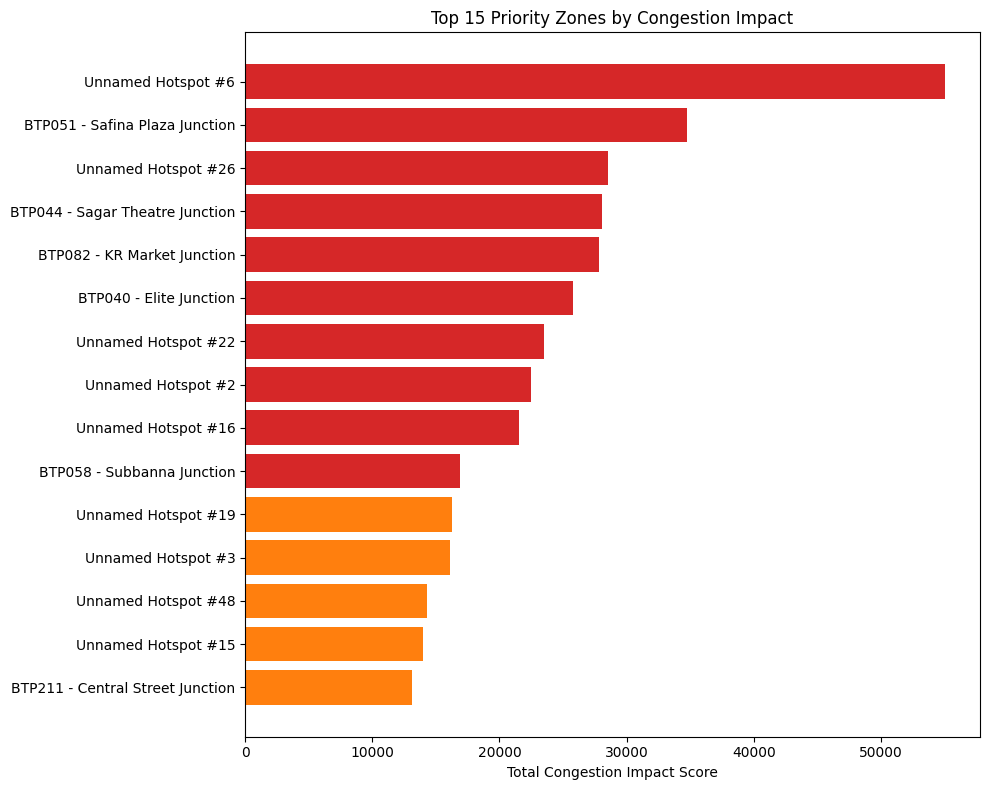

In [ ]:
# Cell: top 15 zones - impact score bar chart
fig, ax = plt.subplots(figsize=(10, 8))
top15 = combined.head(15).sort_values('total_impact')

colors = ['#d62728' if r <= 10 else '#ff7f0e' for r in top15['priority_rank']]
ax.barh(top15['junction_name'], top15['total_impact'], color=colors)
ax.set_xlabel('Total Congestion Impact Score')
ax.set_title('Top 15 Priority Zones by Congestion Impact')
plt.tight_layout()
plt.savefig('top_zones_impact.png', dpi=150)
plt.show()

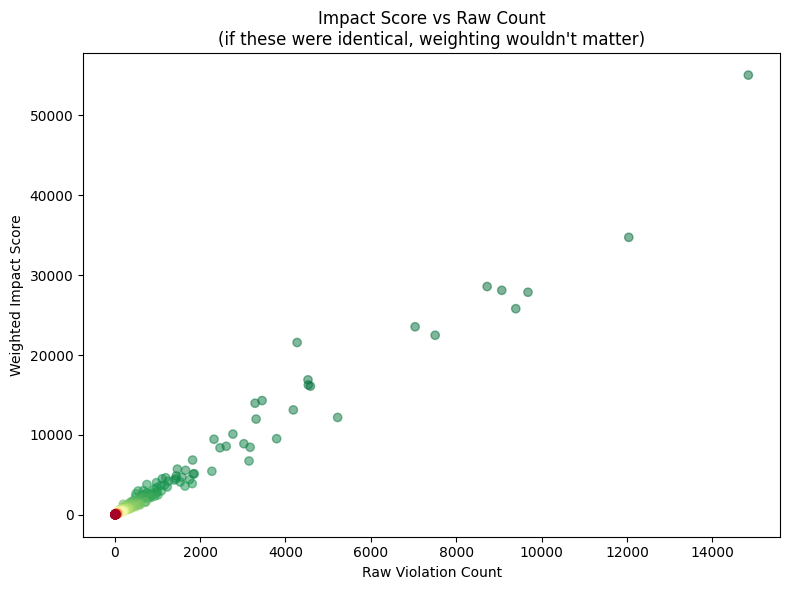

Correlation: 0.987


In [ ]:
# Cell: violation count vs impact score - shows your weighting adds real signal, not just count
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(combined['violation_count'], combined['total_impact'], alpha=0.5, c=combined['priority_rank'], cmap='RdYlGn_r')
ax.set_xlabel('Raw Violation Count')
ax.set_ylabel('Weighted Impact Score')
ax.set_title('Impact Score vs Raw Count\n(if these were identical, weighting wouldn\'t matter)')
plt.tight_layout()
plt.savefig('count_vs_impact.png', dpi=150)
plt.show()

corr = combined['violation_count'].corr(combined['total_impact'])
print(f"Correlation: {corr:.3f}")

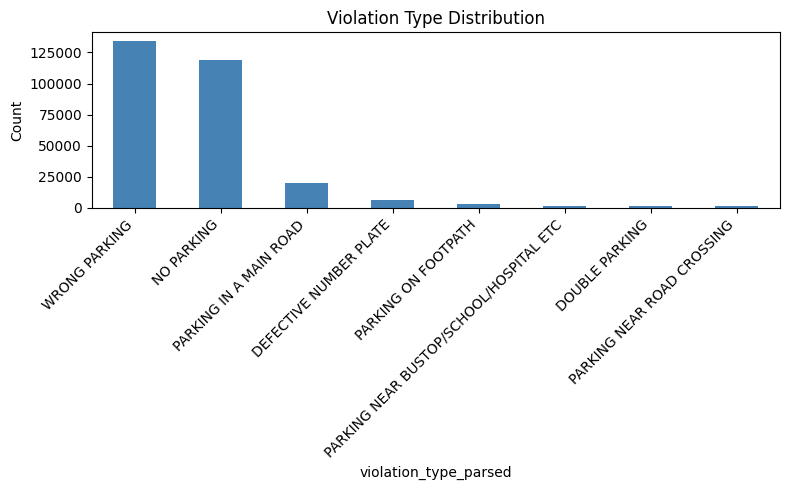

In [ ]:
# Cell: violation type breakdown - what's actually driving the impact
violation_type_flat = df_clean.explode('violation_type_parsed')
type_counts = violation_type_flat['violation_type_parsed'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(8, 5))
type_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Violation Type Distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('violation_types.png', dpi=150)
plt.show()

In [ ]:
# Cell: clean, presentable enforcement priority table
display_table = combined.head(15)[['priority_rank','junction_name','police_station','violation_count','total_impact']].copy()
display_table.columns = ['Rank', 'Zone', 'Police Station', 'Violations', 'Impact Score']
display_table['Impact Score'] = display_table['Impact Score'].round(0).astype(int)

# style it for demo screenshot
styled = display_table.style.background_gradient(subset=['Impact Score'], cmap='Reds').hide(axis='index')
styled

Rank,Zone,Police Station,Violations,Impact Score
1,Unnamed Hotspot #6,HAL Old Airport,14842,55026
2,BTP051 - Safina Plaza Junction,Shivajinagar,12042,34728
3,Unnamed Hotspot #26,Malleshwaram,8724,28570
4,BTP044 - Sagar Theatre Junction,Upparpet,9067,28096
5,BTP082 - KR Market Junction,City Market,9681,27857
6,BTP040 - Elite Junction,Upparpet,9395,25800
7,Unnamed Hotspot #22,Malleshwaram,7037,23535
8,Unnamed Hotspot #2,Shivajinagar,7507,22475
9,Unnamed Hotspot #16,Chikkajala,4274,21568
10,BTP058 - Subbanna Junction,Upparpet,4528,16898


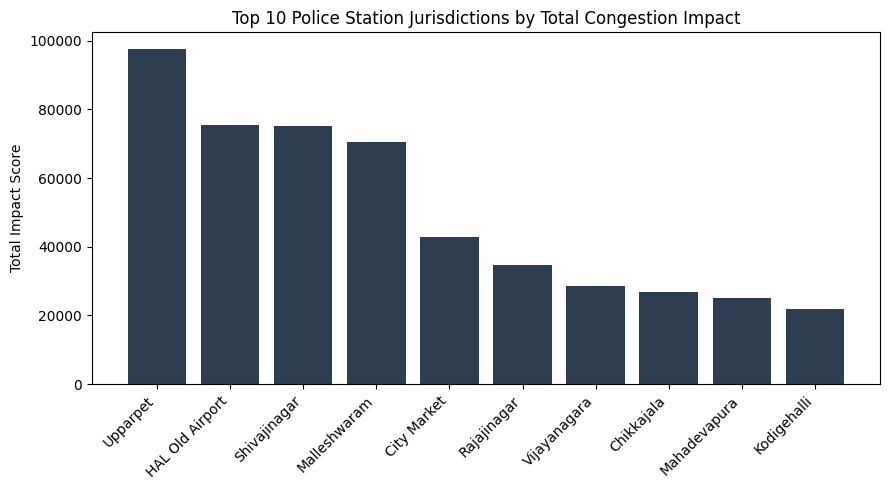

,police_station,total_zones,total_impact
0,Upparpet,7,97520.50
1,HAL Old Airport,7,75328.75
2,Shivajinagar,6,75054.50
3,Malleshwaram,8,70492.50
4,City Market,8,42721.25
5,Rajajinagar,17,34731.00
6,Vijayanagara,13,28564.00
7,Chikkajala,7,26899.00
8,Mahadevapura,16,25171.00
9,Kodigehalli,13,21758.75


In [ ]:
# Cell: police station rollup - "where to deploy resources by jurisdiction"
station_summary = (
    combined.groupby('police_station')
    .agg(total_zones=('junction_name','count'), total_impact=('total_impact','sum'))
    .sort_values('total_impact', ascending=False)
    .reset_index()
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(station_summary['police_station'], station_summary['total_impact'], color='#2c3e50')
ax.set_ylabel('Total Impact Score')
ax.set_title('Top 10 Police Station Jurisdictions by Total Congestion Impact')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('station_summary.png', dpi=150)
plt.show()

station_summary

### Goal 3: Actionable Targeted Enforcement

**Outcome:** We generated a prioritized enforcement plan organized by police jurisdiction. By integrating the spatial heatmap with impact scores, we move enforcement from reactive patrolling to a data-driven, preemptive deployment strategy.

**Deployment:** The plan provides the 'where' (top 15 zones) and 'who' (responsible police station) for immediate resource allocation.